# Customer Churn: Insights

This notebook is part of a multi-notebook customer churn project.

The goal of this notebook is to build on the cleaned dataset from Notebook 1 and identify customer segments with the highest churn risk. Instead of only looking at one feature at a time, this notebook combines customer characteristics such as contract type, tenure, internet service, payment method, monthly charges, and support services.


## Project Notebooks

1. **Customer Churn: EDA**  
   Cleans the dataset, creates churn-related features, and explores major churn patterns.

2. **Customer Churn: Insights**  
   Builds customer segments and identifies high-risk churn groups.

3. **Customer Churn: Modeling**  
   Trains machine learning models to predict customer churn.

4. **Customer Churn: Recommendations**  
   Interprets segment and model results and turns findings into retention recommendations.


## Notebook Goals

In this notebook, we will:

- Load the cleaned dataset from Notebook 1
- Compare churn across customer segments
- Identify the highest-risk customer groups
- Analyze how multiple churn risk factors interact
- Save segment summary outputs for the final recommendations notebook


In [1]:
from pathlib import Path
import os

print("Available Kaggle input files, if running on Kaggle:")
if Path("/kaggle/input").exists():
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            print(os.path.join(dirname, filename))
else:
    print("Not running in Kaggle; local outputs will be used.")


/kaggle/input/notebooks/anav24/customer-churn-eda/__results__.html
/kaggle/input/notebooks/anav24/customer-churn-eda/telco_churn_cleaned.csv
/kaggle/input/notebooks/anav24/customer-churn-eda/__notebook__.ipynb
/kaggle/input/notebooks/anav24/customer-churn-eda/__output__.json
/kaggle/input/notebooks/anav24/customer-churn-eda/custom.css
/kaggle/input/notebooks/anav24/customer-churn-eda/__results___files/__results___15_0.png
/kaggle/input/notebooks/anav24/customer-churn-eda/__results___files/__results___20_0.png
/kaggle/input/notebooks/anav24/customer-churn-eda/__results___files/__results___25_0.png
/kaggle/input/notebooks/anav24/customer-churn-eda/__results___files/__results___36_0.png
/kaggle/input/notebooks/anav24/customer-churn-eda/__results___files/__results___27_0.png
/kaggle/input/notebooks/anav24/customer-churn-eda/__results___files/__results___17_0.png
/kaggle/input/notebooks/anav24/customer-churn-eda/__results___files/__results___23_0.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

possible_data_paths = [
    Path("/kaggle/input/notebooks/anav24/customer-churn-eda/telco_churn_cleaned.csv"),
    Path("outputs/telco_churn_cleaned.csv"),
    Path("../outputs/telco_churn_cleaned.csv"),
    Path("telco_churn_cleaned.csv"),
]

file_path = next((path for path in possible_data_paths if path.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        "Cleaned dataset not found. Run customer-churn-eda.ipynb first, "
        "or place telco_churn_cleaned.csv in the outputs/ folder."
    )

df = pd.read_csv(file_path)

print("Loaded from:", file_path)
print("Shape:", df.shape)
df.head()


Shape: (7043, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Tenure_Group,Risk_Factor_Count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,3
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,5


## Verify Cleaned Dataset

The cleaned dataset from Notebook 1 loaded successfully. It includes the original customer fields plus the engineered churn columns created during EDA.

In [3]:
print("Shape:", df.shape)
print("Overall churn rate:", f"{df['Churn_Flag'].mean():.2%}")

df[["Churn", "Churn_Flag", "Tenure_Group", "Risk_Factor_Count"]].head()

Shape: (7043, 24)
Overall churn rate: 26.54%


,Churn,Churn_Flag,Tenure_Group,Risk_Factor_Count
0,No,0,0-12 months,3
1,No,0,25-48 months,0
2,Yes,1,0-12 months,2
3,No,0,25-48 months,0
4,Yes,1,0-12 months,5


## Customer Segmentation

To better understand churn risk, this section groups customers by combinations of important features. This helps identify customer segments that may need targeted retention strategies.

In [4]:
def segment_summary(group_cols):
    summary = (
        df
        .groupby(group_cols)["Churn_Flag"]
        .agg(Customer_Count="count", Churn_Rate="mean")
        .reset_index()
        .sort_values("Churn_Rate", ascending=False)
    )

    summary["Churn_Rate_%"] = summary["Churn_Rate"] * 100

    return summary

## Segment 1: Contract Type and Tenure

Notebook 1 showed that month-to-month contracts and newer customers are both associated with higher churn. This section combines those two features to see which contract-tenure groups are most at risk.

In [5]:
contract_tenure_segments = segment_summary(["Contract", "Tenure_Group"])

contract_tenure_segments

,Contract,Tenure_Group,Customer_Count,Churn_Rate,Churn_Rate_%
0,Month-to-month,0-12 months,1994,0.513541,51.354062
1,Month-to-month,13-24 months,737,0.377205,37.720488
2,Month-to-month,25-48 months,802,0.329177,32.917706
3,Month-to-month,49-72 months,342,0.260234,26.023392
7,One year,49-72 months,634,0.129338,12.933754
6,One year,25-48 months,518,0.106178,10.617761
4,One year,0-12 months,124,0.104839,10.483871
5,One year,13-24 months,197,0.081218,8.121827
11,Two year,49-72 months,1263,0.033254,3.325416
10,Two year,25-48 months,274,0.021898,2.189781


In [6]:
contract_tenure_segments_filtered = contract_tenure_segments[
    contract_tenure_segments["Customer_Count"] >= 100
]

contract_tenure_segments_filtered

,Contract,Tenure_Group,Customer_Count,Churn_Rate,Churn_Rate_%
0,Month-to-month,0-12 months,1994,0.513541,51.354062
1,Month-to-month,13-24 months,737,0.377205,37.720488
2,Month-to-month,25-48 months,802,0.329177,32.917706
3,Month-to-month,49-72 months,342,0.260234,26.023392
7,One year,49-72 months,634,0.129338,12.933754
6,One year,25-48 months,518,0.106178,10.617761
4,One year,0-12 months,124,0.104839,10.483871
5,One year,13-24 months,197,0.081218,8.121827
11,Two year,49-72 months,1263,0.033254,3.325416
10,Two year,25-48 months,274,0.021898,2.189781


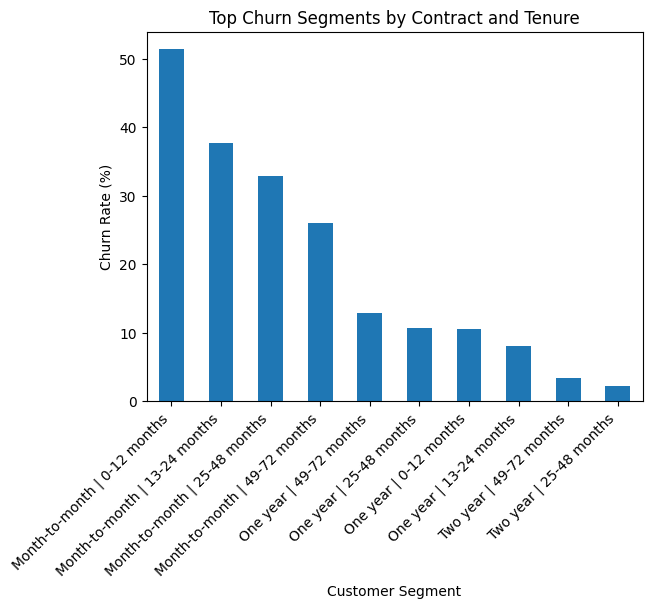

In [7]:
top_contract_tenure = contract_tenure_segments_filtered.head(10).copy()

top_contract_tenure["Segment"] = (
    top_contract_tenure["Contract"].astype(str)
    + " | "
    + top_contract_tenure["Tenure_Group"].astype(str)
)

top_contract_tenure.plot(
    kind="bar",
    x="Segment",
    y="Churn_Rate_%",
    legend=False
)

plt.title("Top Churn Segments by Contract and Tenure")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Contract and Tenure Segment Findings

The highest-risk segment is customers on month-to-month contracts with 0-12 months of tenure. This group has 1,994 customers and a churn rate of 51.35%.

Churn remains high for month-to-month customers across every tenure group. Even month-to-month customers with 49-72 months of tenure churn at 26.02%, which is much higher than most one-year and two-year contract segments.

Longer contracts show much lower churn. One-year contract segments stay near 8-13% churn, while two-year contract customers have the lowest churn rates in the filtered results.

This suggests that contract type is one of the strongest retention signals. New month-to-month customers should be treated as a priority retention group.

## Segment 2: Internet Service and Payment Method

Notebook 1 showed that fiber optic customers and electronic check users had high churn rates. This section combines internet service type and payment method to identify whether certain billing-service combinations are especially risky.

In [8]:
internet_payment_segments = segment_summary(["InternetService", "PaymentMethod"])

internet_payment_segments

,InternetService,PaymentMethod,Customer_Count,Churn_Rate,Churn_Rate_%
6,Fiber optic,Electronic check,1595,0.532288,53.228840
7,Fiber optic,Mailed check,258,0.426357,42.635659
2,DSL,Electronic check,648,0.319444,31.944444
4,Fiber optic,Bank transfer (automatic),646,0.289474,28.947368
5,Fiber optic,Credit card (automatic),597,0.252931,25.293132
3,DSL,Mailed check,613,0.207178,20.717781
10,No,Electronic check,122,0.122951,12.295082
1,DSL,Credit card (automatic),594,0.121212,12.121212
11,No,Mailed check,741,0.095816,9.581646
0,DSL,Bank transfer (automatic),566,0.093640,9.363958


In [9]:
internet_payment_segments_filtered = internet_payment_segments[
    internet_payment_segments["Customer_Count"] >= 100
]

internet_payment_segments_filtered

,InternetService,PaymentMethod,Customer_Count,Churn_Rate,Churn_Rate_%
6,Fiber optic,Electronic check,1595,0.532288,53.228840
7,Fiber optic,Mailed check,258,0.426357,42.635659
2,DSL,Electronic check,648,0.319444,31.944444
4,Fiber optic,Bank transfer (automatic),646,0.289474,28.947368
5,Fiber optic,Credit card (automatic),597,0.252931,25.293132
3,DSL,Mailed check,613,0.207178,20.717781
10,No,Electronic check,122,0.122951,12.295082
1,DSL,Credit card (automatic),594,0.121212,12.121212
11,No,Mailed check,741,0.095816,9.581646
0,DSL,Bank transfer (automatic),566,0.093640,9.363958


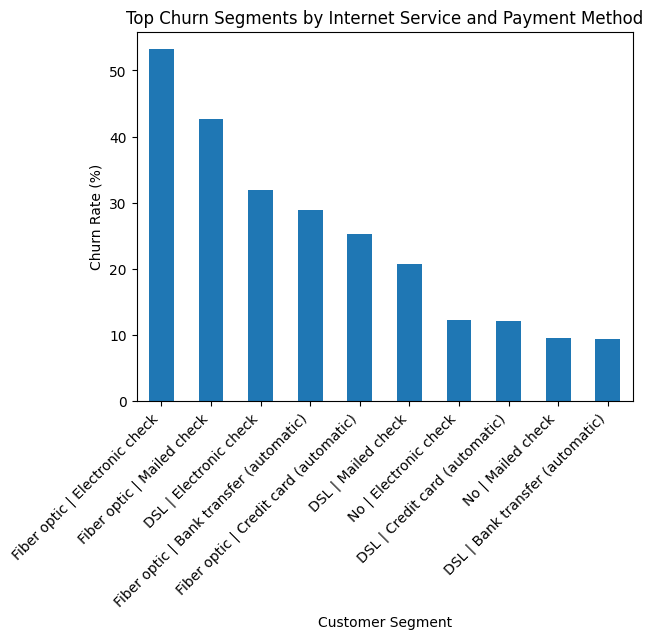

In [10]:
top_internet_payment = internet_payment_segments_filtered.head(10).copy()

top_internet_payment["Segment"] = (
    top_internet_payment["InternetService"].astype(str)
    + " | "
    + top_internet_payment["PaymentMethod"].astype(str)
)

top_internet_payment.plot(
    kind="bar",
    x="Segment",
    y="Churn_Rate_%",
    legend=False
)

plt.title("Top Churn Segments by Internet Service and Payment Method")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Internet Service and Payment Method Findings

The highest-risk segment is fiber optic customers who pay by electronic check. This group has 1,595 customers and a churn rate of 53.23%.

Fiber optic customers show high churn across all payment methods, but churn is highest when fiber optic service is combined with electronic check payments. Fiber optic customers using mailed checks also have high churn at 42.64%.

DSL customers generally have lower churn than fiber optic customers, but DSL customers using electronic checks still churn at 31.94%. Customers with no internet service have the lowest churn rates overall.

This suggests that internet service type and payment method are important churn signals. Fiber optic customers using electronic checks should be considered a high-priority retention segment.

## Segment 3: Support Services

Notebook 1 showed that customers without online security or tech support had higher churn. This section combines those two features to see whether customers missing both support-related services are especially likely to churn.

In [11]:
support_segments = segment_summary(["OnlineSecurity", "TechSupport"])

support_segments

,OnlineSecurity,TechSupport,Customer_Count,Churn_Rate,Churn_Rate_%
0,No,No,2553,0.489620,48.962005
1,No,Yes,945,0.223280,22.328042
3,Yes,No,920,0.213043,21.304348
4,Yes,Yes,1099,0.090082,9.008189
2,No internet service,No internet service,1526,0.074050,7.404980


In [12]:
support_segments_filtered = support_segments[
    support_segments["Customer_Count"] >= 100
]

support_segments_filtered

,OnlineSecurity,TechSupport,Customer_Count,Churn_Rate,Churn_Rate_%
0,No,No,2553,0.489620,48.962005
1,No,Yes,945,0.223280,22.328042
3,Yes,No,920,0.213043,21.304348
4,Yes,Yes,1099,0.090082,9.008189
2,No internet service,No internet service,1526,0.074050,7.404980


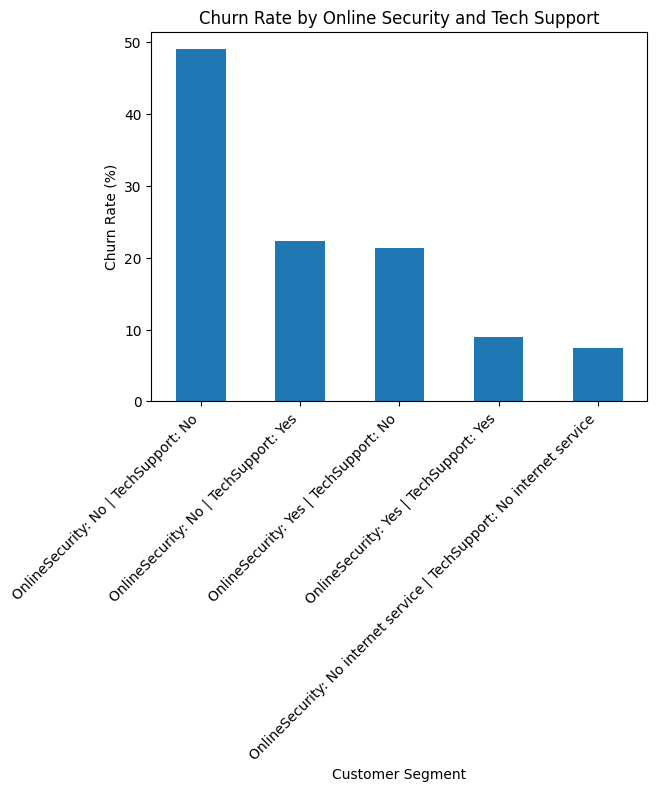

In [13]:
top_support_segments = support_segments_filtered.head(10).copy()

top_support_segments["Segment"] = (
    "OnlineSecurity: "
    + top_support_segments["OnlineSecurity"].astype(str)
    + " | TechSupport: "
    + top_support_segments["TechSupport"].astype(str)
)

top_support_segments.plot(
    kind="bar",
    x="Segment",
    y="Churn_Rate_%",
    legend=False
)

plt.title("Churn Rate by Online Security and Tech Support")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Support Services Findings

Customers without both online security and tech support have the highest churn rate in this segment analysis. This group includes 2,553 customers and has a churn rate of 48.96%.

Customers with either online security or tech support have lower churn, around 21-22%. Customers with both services have a much lower churn rate of 9.01%.

This suggests that support-related services may be associated with stronger retention. Customers who lack both online security and tech support should be considered a high-risk group for churn.

## Segment 4: High-Risk Customer Profiles

The previous sections showed that churn risk increases when certain customer traits appear together. This section combines several high-risk traits to identify the customer profiles most likely to churn.

In [14]:
high_risk_profile = df[
    (df["Contract"] == "Month-to-month") &
    (df["Tenure_Group"] == "0-12 months") &
    (df["InternetService"] == "Fiber optic") &
    (df["PaymentMethod"] == "Electronic check")
]

print("High-risk profile customer count:", len(high_risk_profile))
print("High-risk profile churn rate:", f"{high_risk_profile['Churn_Flag'].mean():.2%}")

high_risk_profile.head()

High-risk profile customer count: 631
High-risk profile churn rate: 71.16%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Tenure_Group,Risk_Factor_Count
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,5
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,0-12 months,5
36,6047-YHPVI,Male,0,No,No,5,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,316.90,Yes,1,0-12 months,4
47,7760-OYPDY,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.65,144.15,Yes,1,0-12 months,5
64,5698-BQJOH,Female,0,No,No,9,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,94.40,857.25,Yes,1,0-12 months,5


For readability, the combined high-risk group is labeled as **High-Risk Profile** in the summary table and chart.

In [15]:
profile_summary = pd.DataFrame({
    "Segment": [
        "Overall Customer Base",
        "High-Risk Profile"
    ],
    "Customer_Count": [
        len(df),
        len(high_risk_profile)
    ],
    "Churn_Rate_%": [
        df["Churn_Flag"].mean() * 100,
        high_risk_profile["Churn_Flag"].mean() * 100
    ]
})

profile_summary

,Segment,Customer_Count,Churn_Rate_%
0,Overall Customer Base,7043,26.536987
1,High-Risk Profile,631,71.156894


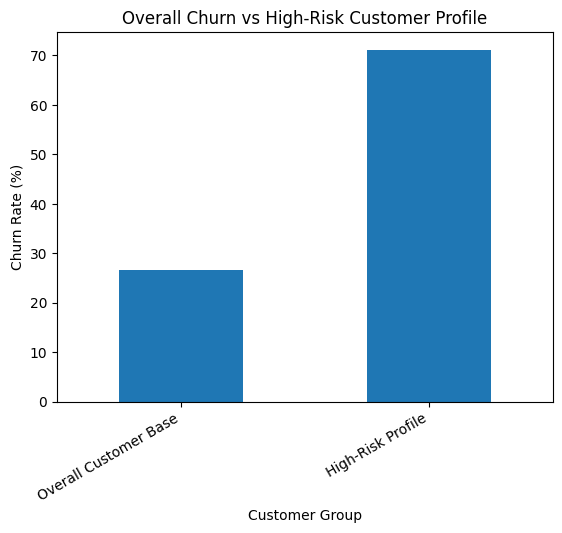

In [16]:
profile_summary.plot(
    kind="bar",
    x="Segment",
    y="Churn_Rate_%",
    legend=False
)

plt.title("Overall Churn vs High-Risk Customer Profile")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

## High-Risk Profile Findings

The high-risk profile combines four churn-related traits:

- Month-to-month contract
- 0-12 months of tenure
- Fiber optic internet service
- Electronic check payment method

This segment contains 631 customers and has a churn rate of 71.16%, compared with the overall customer churn rate of 26.54%.

This means the high-risk profile churns at nearly three times the overall customer rate. This is one of the clearest business findings in the project so far. Customers in this group should be a top priority for retention campaigns, onboarding support, billing review, and service satisfaction follow-up.

## Segment 5: Risk Factor Count

Notebook 1 created a simple `Risk_Factor_Count` column based on five churn-related conditions. This section uses that score to compare churn across customers with different numbers of risk factors.

In [17]:
risk_factor_summary = (
    df
    .groupby("Risk_Factor_Count")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
    .reset_index()
)

risk_factor_summary["Churn_Rate_%"] = risk_factor_summary["Churn_Rate"] * 100

risk_factor_summary

,Risk_Factor_Count,Customer_Count,Churn_Rate,Churn_Rate_%
0,0,1376,0.025436,2.543605
1,1,1150,0.083478,8.347826
2,2,1762,0.204881,20.488082
3,3,1197,0.348371,34.837093
4,4,1018,0.561886,56.188605
5,5,540,0.718519,71.851852


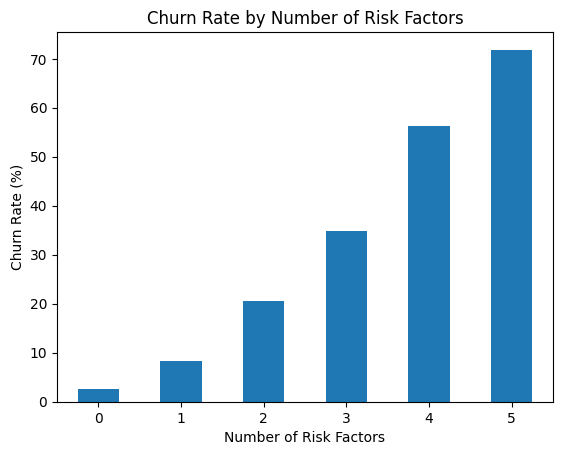

In [18]:
risk_factor_summary.plot(
    kind="bar",
    x="Risk_Factor_Count",
    y="Churn_Rate_%",
    legend=False
)

plt.title("Churn Rate by Number of Risk Factors")
plt.xlabel("Number of Risk Factors")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [19]:
risk_factor_summary["Customer_Share_%"] = (
    risk_factor_summary["Customer_Count"] / len(df) * 100
)

risk_factor_summary[["Risk_Factor_Count", "Customer_Count", "Customer_Share_%", "Churn_Rate_%"]]

,Risk_Factor_Count,Customer_Count,Customer_Share_%,Churn_Rate_%
0,0,1376,19.537129,2.543605
1,1,1150,16.328269,8.347826
2,2,1762,25.017748,20.488082
3,3,1197,16.995598,34.837093
4,4,1018,14.454068,56.188605
5,5,540,7.667187,71.851852


## Risk Factor Count Findings

The risk factor score shows a clear pattern: churn increases as customers have more risk factors.

Customers with 0 risk factors have a churn rate of only 2.54%. Customers with 3 risk factors churn at 34.84%, and customers with all 5 risk factors churn at 71.85%.

This is one of the strongest findings in the project because it shows that churn risk is cumulative. A single risk factor may not fully explain churn, but customers become much more likely to leave when several risk factors appear together.

## Key High-Risk Segments

This table summarizes the major high-risk customer groups identified in this notebook.

In [20]:
key_segments = pd.DataFrame({
    "Segment": [
        "Month-to-month + 0-12 months",
        "Fiber optic + Electronic check",
        "No online security + No tech support",
        "High-risk profile",
        "5 risk factors"
    ],
    "Customer_Count": [
        1994,
        1595,
        2553,
        631,
        540
    ],
    "Churn_Rate_%": [
        51.354062,
        53.228840,
        48.962005,
        71.156894,
        71.851852
    ]
})

key_segments

,Segment,Customer_Count,Churn_Rate_%
0,Month-to-month + 0-12 months,1994,51.354062
1,Fiber optic + Electronic check,1595,53.228840
2,No online security + No tech support,2553,48.962005
3,High-risk profile,631,71.156894
4,5 risk factors,540,71.851852


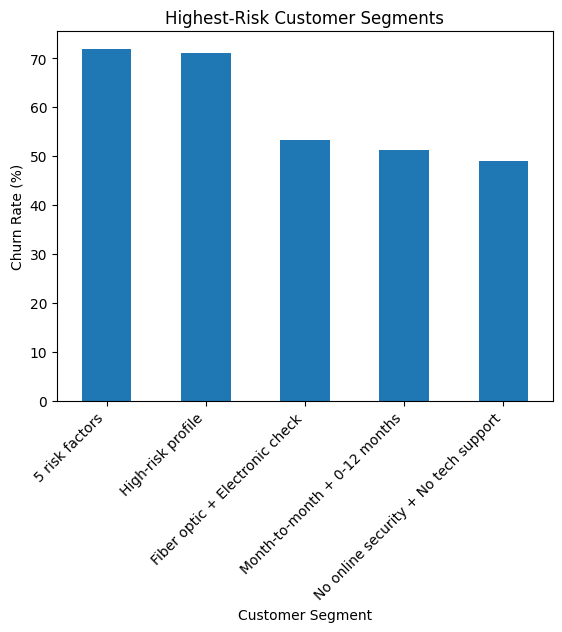

In [21]:
key_segments.sort_values("Churn_Rate_%", ascending=False).plot(
    kind="bar",
    x="Segment",
    y="Churn_Rate_%",
    legend=False
)

plt.title("Highest-Risk Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Insights Conclusion

This notebook expanded the churn analysis by combining customer traits into business-focused segments.

The strongest high-risk groups were:

1. Customers with all 5 risk factors, with a churn rate of 71.85%
2. The high-risk profile group, with a churn rate of 71.16%
3. Fiber optic customers using electronic checks, with a churn rate of 53.23%
4. Month-to-month customers with 0-12 months of tenure, with a churn rate of 51.35%
5. Customers without both online security and tech support, with a churn rate of 48.96%

The analysis shows that churn risk is not driven by one feature alone. Churn becomes much more likely when multiple risk factors appear together, especially short tenure, month-to-month contracts, fiber optic service, electronic check payments, and missing support services.

These findings can guide retention strategies such as improved onboarding for new customers, targeted support for month-to-month customers, billing/payment outreach, and service quality follow-up for fiber optic customers.

The next notebook will use these patterns to build machine learning models that predict customer churn.

In [22]:
from pathlib import Path

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
if not output_dir.exists() and Path("../outputs").exists():
    output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

contract_tenure_segments_filtered.to_csv(output_dir / "contract_tenure_segments.csv", index=False)
contract_tenure_segments_filtered.to_csv(output_dir / "customer_tenure_segments.csv", index=False)
internet_payment_segments_filtered.to_csv(output_dir / "internet_payment_segments.csv", index=False)
support_segments_filtered.to_csv(output_dir / "support_segments.csv", index=False)
risk_factor_summary.to_csv(output_dir / "risk_factor_summary.csv", index=False)
key_segments.to_csv(output_dir / "key_churn_segments.csv", index=False)

print(f"Notebook 2 segment outputs saved to {output_dir}")


Notebook 2 segment outputs saved.
